In [1]:
import numpy as np
def diagonalize_sorted(A):
    v, u = np.linalg.eigh(A)
    idx = v.argsort()[::-1]
    v = v[idx]
    u = u[:, idx]
    return v, u

def svd2(A):
    u,s,vt = np.linalg.svd(A, full_matrices=False)
    return u, s, vt

def svd(A):
    A = A.astype(float)
    m, n = A.shape
    r = min(m, n)

    # 1) Diagonalisation de A^T A pour obtenir V et les valeurs singulieres
    eigvals, V = diagonalize_sorted(A.T @ A)
    eigvals = np.clip(eigvals[:r], 0.0, None)
    S = np.sqrt(eigvals)
    V = V[:, :r]

    # 2) Construire U via u_i = A v_i / s_i pour garder le bon appariement
    U = np.zeros((m, r), dtype=float)
    for i in range(r):
        ui = (A @ V[:, i]) / S[i]
        nrm = np.linalg.norm(ui)
        U[:, i] = ui / nrm

    Vt = V.T
    return U, S, Vt

In [2]:
from PIL import Image
import matplotlib.pyplot as plt

image = Image.open('Photo-montagne-noir-et-blanc-aiguille-verte.jpg')
imageGrey = image.convert("L")
imageData = np.asarray(imageGrey)
print(imageData)
np.savetxt("imageData.txt", imageData, fmt="%d")
print("imageData sauvegardé dans imageData.txt")

[[ 90  90  90 ...  84  84  84]
 [ 90  90  90 ...  85  85  85]
 [ 90  90  90 ...  85  85  85]
 ...
 [231 228 227 ... 215 157 122]
 [226 225 220 ... 164 221 214]
 [222 220 223 ... 202 200 209]]
imageData sauvegardé dans imageData.txt


In [3]:
import mps_library as mps_lib
U, S, Vt = mps_lib.svd_for_tensor_compression(imageData,1,tol=1e-1)



In [4]:
def back_to_matrix(U, S, Vt, k):
    if k is None:
        k = len(S)
    k = min(k, len(S), U.shape[1], Vt.shape[0])
    return np.dot(U[:, :k], np.dot(np.diag(S[:k]), Vt[:k, :]))

In [8]:
k = 300
M = back_to_matrix(U, S, Vt, k=k)
print(M.shape)
img = Image.fromarray(np.clip(np.rint(M), 0, 255).astype(np.uint8), 'L')
img.show()

(801, 1200)


In [1]:
import mps_class 
import numpy as np
import mps_library as mps_lib

tensor = np.random.normal(0, 1, (110, 130))
tensor = np.random.rand(110, 130)
u,s,vt =mps_lib.svd_for_tensor_compression(tensor,1,tol=100)
print(s)
print("shapes: u:", u.shape, "s:", s.shape, "vt:", vt.shape)
tensor_approx = np.tensordot(u, np.tensordot(np.diag(s), vt, axes=(1, 0)), axes=(1, 0))
print("Original tensor shape:", tensor.shape)
print("Approximated tensor shape:", tensor_approx.shape)
print("Original tensor norm:\n", np.linalg.norm(tensor))
print("Approximated tensor norm:\n", np.linalg.norm(tensor_approx))

[60.02299071  6.01490852  5.97599544  5.91431352  5.83292055  5.60126928
  5.55973897  5.50707873  5.44110725  5.35904843  5.29039174  5.16687538
  5.11877435  5.04307818  4.98856831  4.84666152  4.83808299  4.76179616
  4.64297414  4.6197189   4.57340283  4.48670042  4.40502748  4.358714
  4.30588532  4.24536623  4.19062608  4.15823989  4.13156969  4.07799076
  4.06822617  3.97856801  3.89003284  3.8380934   3.76658693  3.69682628
  3.68006351  3.62279744  3.60553039  3.53538613  3.4971552   3.48169862
  3.38937494  3.37032494  3.29055531  3.22646737  3.16292772  3.09872137
  3.0767633   3.04285855  2.99302709  2.89067368  2.85164352  2.79585516
  2.76703053  2.75918638  2.67762688  2.64854443  2.59160716  2.52585097
  2.46111615  2.45962034  2.42860978  2.3439153   2.29222372  2.26190936
  2.22322643  2.17736534  2.1557619   2.12764999  2.06356344  2.03227049
  1.97129241  1.91067344  1.90015062  1.85957021  1.75520485  1.71201287
  1.68681692  1.66280062  1.52946215  1.50949041  1.4

In [11]:
list = [1,2,3]
print(list[2:])

[3]


In [1]:
import mps_class 
import numpy as np
import mps_library as mps_lib

tensor = np.random.rand(11, 130, 15, 200)
mps = mps_class.MPS(tensor)
can_mps = mps_class.MPS_Canonical(mps.cores)
eval_vector = [1,2,0,2]
print(tensor[tuple(eval_vector)])
print(mps_class.MPS.mps_evaluation(can_mps.cores, eval_vector))
print(mps_class.MPS.mps_evaluation(mps.cores, eval_vector))
print(can_mps.center)
can_mps.shift_center_left(None)
print([mps.cores[i].shape for i in range(len(mps.cores))])
print([np.linalg.norm(can_mps.cores[i]) for i in range(len(mps.cores))])
print(mps_class.MPS.mps_evaluation(can_mps.cores, eval_vector))
can_mps.shift_center_left(1e-1)
print([np.linalg.norm(can_mps.cores[i]) for i in range(len(mps.cores))])
print(mps_class.MPS.mps_evaluation(can_mps.cores, eval_vector))
can_mps.shift_center_right(1)
print([np.linalg.norm(can_mps.cores[i]) for i in range(len(mps.cores))])
print(mps_class.MPS.mps_evaluation(can_mps.cores, eval_vector))
print(can_mps.center)
print('tensor norm' , np.linalg.norm(tensor))
print('mps norm' , can_mps.norm())


0.18271694693790463
0.18271694693790397
0.18271694693790447
3
[(1, 11, 11), (11, 130, 1430), (1430, 15, 200), (200, 200, 1)]
[3.3166247903554003, 37.81534080237808, 1195.2167724574638, 14.142135623730951]
0.18271694693790383
[3.3166247903554003, 1189.2449380342246, 34.13209633175203, 14.142135623730951]
0.19323215430273333
[3.3166247903554003, 1.0, 1035.1947270763706, 14.142135623730951]
0.491867015382227
2
tensor norm 1195.2167724574624
mps norm 1035.1947270763706


In [4]:
import mps_class 
import numpy as np
import mps_library as mps_lib
import mpo_class

tensor = np.random.rand(3, 5, 7)
mps_can = mps_class.MPS_Canonical(tensor)
print(mps_can.center)
mps_can.shift_center_left(None)
print(mps_can.cores)


2
[array([[[-0.6281078 , -0.40336855, -0.66541296],
        [-0.55660421, -0.36467348,  0.74646166],
        [-0.54375761,  0.83923004,  0.00453763]]]), array([[[ 2.70038103e+00,  2.62068359e-01, -1.42935642e-01,
          1.06208445e-01, -2.13830591e-01, -1.16444188e-01,
         -2.69969034e-01],
        [ 1.97824647e+00, -1.05203713e-01,  6.06751218e-01,
          8.66318742e-02,  9.24202719e-02, -4.30168047e-01,
          1.85437019e-01],
        [ 2.47788958e+00, -3.91237182e-01, -1.84739368e-01,
         -1.53647073e-01,  1.75981831e-01,  3.34255232e-01,
          1.20615738e-01],
        [ 2.07299984e+00, -3.01013208e-01, -6.79580570e-01,
          1.60028270e-01, -2.53220459e-01, -6.90258292e-02,
          1.43388333e-01],
        [ 2.10516608e+00,  4.88556259e-01,  3.64989186e-01,
         -2.61488230e-01,  3.02142408e-01,  1.49288283e-01,
         -1.33864911e-01]],

       [[-2.41715518e-01, -5.80093124e-01,  1.81410544e-02,
          1.31648281e-01, -1.01444977e-01, -5.4732

In [3]:
import mps_class 
import numpy as np
import mps_library as mps_lib
import mpo_class

tensor = np.random.rand(3,3, 5,5, 7,7)
tensor_transposed = np.transpose(tensor, (1,0,3,2,5,4))
ham = tensor + tensor_transposed
hamt = ham.transpose((0,2,4,1,3,5))
mat = hamt.reshape(3*5*7, 3*5*7)

eigvals, eigvect = np.linalg.eigh(mat)

eigvector = eigvect[:,0]
print('true energy',eigvals[0])
eigvector_tensor = eigvector.reshape(3,5,7)
mpo = mpo_class.MPO(ham)
mps = mps_class.MPS_Canonical(eigvector_tensor)
mps.shift_center_left(None)
#mps.shift_center_left(None)
print("energy:", mpo.expectation_value(mps))


true energy -8.088381124313598
energy: -8.088381124313575


In [5]:
H_eff = mpo.H_eff(mps)
print("H_eff shape:", H_eff.shape)
H_eff_matrix = H_eff.reshape(3*5*7, 3*5*7)
eigvals_eff, eigvect_eff = np.linalg.eigh(H_eff_matrix)
eigvector_eff = eigvect_eff[:,0]
eigvector_eff_tensor = eigvector_eff.reshape(3,5,7)
print(np.linalg.norm(eigvector_eff_tensor - mps.cores[mps.center]))


H_eff shape: (3, 5, 7, 3, 5, 7)
1.9999999999999984


true energy: -8.962013194479324


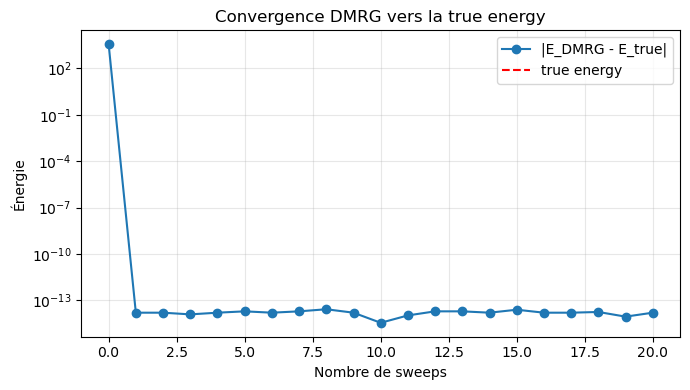

DMRG final energy: -8.96201319447934


In [2]:
import mps_class 
import numpy as np
import mps_library as mps_lib
import mpo_class
import DMRG 
import matplotlib.pyplot as plt

shape = tuple([2] * 14)
tensor = np.random.rand(*shape)
transpose = (1,0,3,2,5,4,7,6,9,8,11,10,13,12)
tensor_transposed = np.transpose(tensor, transpose)
ham = tensor + tensor_transposed
hamt = ham.transpose((0,2,4,6,8,10,12,1,3,5,7,9,11,13))
mat = hamt.reshape(2**7, 2**7)

# Référence exacte
eigvals, eigvect = np.linalg.eigh(mat)
true_energy = eigvals[0]
print("true energy:", true_energy)

# Construction MPO + état initial
mpo = mpo_class.MPO(ham)
mps_init = mps_class.MPS_Canonical(np.random.rand(*tuple([2] * 7))) # mettre le centre à droite pour commencer les sweeps

# Convergence DMRG sweep par sweep
n_sweeps_max = 20
energies_dmrg = [mpo.expectation_value(mps_init)]  # énergie initiale (sweep 0)

for i in range(n_sweeps_max):
    mps_init = DMRG.dmrg(mpo, mps_init, 1,None)
    energies_dmrg.append(mpo.expectation_value(mps_init))

# Plot
sweeps = np.arange(0, n_sweeps_max + 1)
plt.figure(figsize=(7, 4))
plt.plot(sweeps, np.abs(energies_dmrg - true_energy), "o-", label="|E_DMRG - E_true|")
plt.yscale("log")
plt.axhline(true_energy, color="r", linestyle="--", label="true energy")
plt.xlabel("Nombre de sweeps")
plt.ylabel("Énergie")
plt.title("Convergence DMRG vers la true energy")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("DMRG final energy:", energies_dmrg[-1])


In [1]:
import mps_class 
import numpy as np
import mps_library as mps_lib
import mpo_class
import DMRG 
import matplotlib.pyplot as plt

tensor = np.random.rand(5,5, 5,5,5,5,5,5)
tensor2 = np.random.rand(5,5,5,5,5,5,5,5)

eval_vector = [1,2,0,2,3,4,2,2]
mpo = mpo_class.MPO(tensor)
mpo2 = mpo_class.MPO(tensor2)
tensor_sum = tensor + tensor2
print([mpo.cores[i].shape for i in range(len(mpo.cores))])

mpo_add = mpo.addition(mpo2)
print([mpo_add.cores[i].shape for i in range(len(mpo.cores))])
mps_add = mpo_add.mpo_to_mps()
print([mps_add.cores[i].shape for i in range(len(mps_add.cores))])
mps_add.sweep_left(None)
mps_add.sweep_right(None)
mpo_reconstructed = mpo_class.MPO.mps_to_mpo(mps_add)
print([mps_add.cores[i].shape for i in range(len(mps_add.cores))])
print([mpo_reconstructed.cores[i].shape for i in range(len(mpo_reconstructed.cores))])
print("Original sum evaluation:", tensor_sum[tuple(eval_vector)])
print(mpo_reconstructed.evaluate(eval_vector))

[(1, 5, 5, 25), (25, 5, 5, 625), (625, 5, 5, 25), (25, 5, 5, 1)]
[(1, 5, 5, 50), (50, 5, 5, 1250), (1250, 5, 5, 50), (50, 5, 5, 1)]
[(1, 25, 25), (25, 25, 625), (625, 25, 50), (50, 25, 1)]
[(1, 25, 25), (25, 25, 625), (625, 25, 25), (25, 25, 1)]
[(1, 5, 5, 25), (25, 5, 5, 625), (625, 5, 5, 25), (25, 5, 5, 1)]
Original sum evaluation: 0.402132301240961
0.40213230124096233


In [27]:
# Create a random matrix A
A = np.random.rand(10, 10)

# Create block matrix (A A)
block_matrix = np.hstack([A, A])

# Perform QR decomposition on the block matrix
Q, R = np.linalg.qr(block_matrix)

print("Block matrix shape:", block_matrix.shape)
print("Q shape:", Q.shape)
print("R shape:", R.shape)
print("\nQ:\n", Q)
print("\nR:\n", R)
print([R[i,i] for i in range(R.shape[0])])

Block matrix shape: (10, 20)
Q shape: (10, 10)
R shape: (10, 20)

Q:
 [[-0.47521357  0.17239899 -0.15218517 -0.44755018  0.05265177  0.24660896
   0.24163608  0.62425892 -0.05556819  0.07890476]
 [-0.0794694  -0.24324153 -0.49845939  0.36583668 -0.39062372 -0.15913882
   0.32353614  0.09915107  0.33432795  0.38474165]
 [-0.18654276 -0.61396166 -0.27699999  0.21361461  0.34234659  0.00683099
  -0.46937937  0.26154652 -0.20639054 -0.13162145]
 [-0.1078601  -0.20173484 -0.07253168 -0.26171386 -0.68426838  0.15208012
  -0.2124879  -0.06825505  0.14662749 -0.55790071]
 [-0.40504791 -0.06179809  0.54650156  0.1519917  -0.33706691 -0.49746729
  -0.09758273  0.1658486  -0.28351809  0.1784749 ]
 [-0.39155044  0.47043964 -0.46701036 -0.09888093  0.08363912 -0.39697705
  -0.36072665 -0.31893593  0.02957516 -0.01392398]
 [-0.30466361 -0.41338132  0.03103326 -0.27023894  0.2719652  -0.26644425
   0.54862178 -0.40352262  0.01424167 -0.23092645]
 [-0.46784449  0.15381781  0.2752977   0.49507005  0.17

In [ ]:
def full_heisenberg_ham(n_sites, J=1.0):
    I  = np.eye(2, dtype=float)
    Sz = 0.5 * np.array([[1., 0.], [0., -1.]])
    Sp = np.array([[0., 1.], [0.,  0.]])   # S+
    Sm = np.array([[0., 0.], [1.,  0.]])   # S-

    def two_site_term(op_i, op_j, i, n_sites):
        ops = [I] * n_sites
        ops[i]     = op_i
        ops[i + 1] = op_j
        H = ops[0]
        for op in ops[1:]:
            H = np.kron(H, op)
        H = H.reshape([2] * n_sites + [2] * n_sites)
        perm = tuple(np.ravel(np.column_stack((np.arange(n_sites), np.arange(n_sites, 2 * n_sites)))))
        return H.transpose(perm)

    H_full = np.zeros([2] * (2 * n_sites))
    for i in range(n_sites - 1):
        H_full += J * two_site_term(Sz, Sz, i, n_sites)
        H_full += J * 0.5 * two_site_term(Sp, Sm, i, n_sites)
        H_full += J * 0.5 * two_site_term(Sm, Sp, i, n_sites)

    return H_full



0.25


In [17]:
import numpy as np

mat = np.random.rand(4, 4)
tensor = mat.reshape(2, 2, 2, 2).transpose((0, 2, 1, 3))
print(mat[2, 0], tensor[1, 0, 0, 0])

0.6322789138699999 0.6322789138699999
